# Step 3: Fit per-vignette mixed-effects models

For each (model, prompt, vignette) combination, fit:

`admit ~ threatening_z + trustworthy_z + attractive_z 
      + prototypic_z + female_prob_z + race_ambiguity_z 
      + age_rated_z + luminance_z
      + race + gender
      + (1 | photo_id)`

Use `statsmodels.MixedLM` or `lme4` in R. Logistic mixed model on the 20 binary outcomes per face (so the data here is at the run level, 20 rows per face per cell, *not* the aggregated rate).

Per-vignette models tell you which vignettes show effects and which don't — i.e., the vignette-conditional pattern. If Threatening predicts admit in V11 (suicide) and V2 (headache) but not in V9 (red eye), that's a finding about where bias concentrates clinically.

**What you're looking for:**
- Which continuous predictors have non-zero coefficients with confidence intervals not crossing zero, *with race and gender already in the model*?
- Does any predictor show consistent direction across vignettes?
- Compare coefficient on `race` dummies before vs. after adding continuous predictors. If race coefficients shrink toward zero when continuous predictors are included → the "race effect" is partially mediated by perceptual attributes. If race coefficients stay the same → race is doing categorical work the attributes don't capture.

In [6]:
import pandas as pd

AGGREDATED_DATA = "Master_Aggregated_Data.csv"
RUN_DATA = "Master_RunLevel_Data.csv"

print("Loading run-level CSV...")
df = pd.read_csv(RUN_DATA)
df

Loading run-level CSV...


,model,prompt,vignette_id,vignette_class,photo_id,race,gender,response_n,admit_decision,cfd_name,...,attractive_z,babyfaced_z,feminine_z,masculine_z,prototypic_z,threatening_z,trustworthy_z,Unusual_z,luminance_z,race_ambiguity_z
0,llama,baseline,6,borderline,LM_5,L,M,response_n=0.json,1,LM-234,...,0.208458,-0.034590,-0.924790,0.79593,-0.852839,-0.434072,-0.929152,-0.463066,0.612477,0.544172
1,llama,baseline,6,borderline,LM_5,L,M,response_n=1.json,0,LM-234,...,0.208458,-0.034590,-0.924790,0.79593,-0.852839,-0.434072,-0.929152,-0.463066,0.612477,0.544172
2,llama,baseline,6,borderline,LM_5,L,M,response_n=10.json,1,LM-234,...,0.208458,-0.034590,-0.924790,0.79593,-0.852839,-0.434072,-0.929152,-0.463066,0.612477,0.544172
3,llama,baseline,6,borderline,LM_5,L,M,response_n=11.json,0,LM-234,...,0.208458,-0.034590,-0.924790,0.79593,-0.852839,-0.434072,-0.929152,-0.463066,0.612477,0.544172
4,llama,baseline,6,borderline,LM_5,L,M,response_n=12.json,1,LM-234,...,0.208458,-0.034590,-0.924790,0.79593,-0.852839,-0.434072,-0.929152,-0.463066,0.612477,0.544172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71889,qwen,acknowledge,8,borderline,LM_1,L,M,response_n=5.json,0,LM-201,...,1.885927,0.219421,-1.101089,1.17931,-1.995828,-1.156945,2.056942,-0.947809,0.510094,-0.658849
71890,qwen,acknowledge,8,borderline,LM_1,L,M,response_n=6.json,0,LM-201,...,1.885927,0.219421,-1.101089,1.17931,-1.995828,-1.156945,2.056942,-0.947809,0.510094,-0.658849
71891,qwen,acknowledge,8,borderline,LM_1,L,M,response_n=7.json,1,LM-201,...,1.885927,0.219421,-1.101089,1.17931,-1.995828,-1.156945,2.056942,-0.947809,0.510094,-0.658849
71892,qwen,acknowledge,8,borderline,LM_1,L,M,response_n=8.json,1,LM-201,...,1.885927,0.219421,-1.101089,1.17931,-1.995828,-1.156945,2.056942,-0.947809,0.510094,-0.658849


## 3.1 Set up the regression pipeline for Qwen baseline V11

Filter the dataframe to: model=='qwen', prompt=='baseline', vignette_id==11. You'll have 50 rows (one per face) with n_admits and n_total columns.
For logistic mixed-effects regression in Python, the cleanest approach is statsmodels.formula.api.glmer-equivalent, which is pymer4 (wrapper around lme4) or statsmodels.GLM with binomial family on aggregated data. Given your run-level data was 1000 binary outcomes per cell that you've aggregated to 50 face-level cells, you can use either approach:

- Aggregated (50 rows): statsmodels.GLM(family=Binomial()) with var_weights=n_total. Faster, easier. Works because each face's 20 outcomes are exchangeable given the face.
- Run-level (1000 rows): statsmodels.MixedLM or pymer4.glmer. Slower but lets you fit (1|photo_id) random intercepts.

Use run-level data with mixed-effects. It's slower but it's the analysis you actually want. pymer4.models.Lmer with family='binomial'. If pymer4 isn't installed and the install is painful, fall back to statsmodels.MixedLM on logit-transformed admit rates (less ideal but works).

Check if I can safely run the regression

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['threatening_z', 'trustworthy_z', 'attractive_z', 'prototypic_z',
        'female_prob_z', 'race_ambiguity_z', 'age_rated_z', 'luminance_z']].drop_duplicates()
# 50 rows, one per face

vifs = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], 
                  index=X.columns)
print(vifs.sort_values(ascending=False))

attractive_z        2.171488
trustworthy_z       2.150148
race_ambiguity_z    1.709431
luminance_z         1.571728
prototypic_z        1.512868
threatening_z       1.174974
age_rated_z         1.169311
female_prob_z       1.123522
dtype: float64


admit ~ threatening_z + trustworthy_z + attractive_z 
      + prototypic_z + female_prob_z + race_ambiguity_z 
      + age_rated_z + luminance_z
      + race + gender 
      + (1 | photo_id)

In [4]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import numpy as np

lme4 = importr('lme4')

qwen_11_baseline = df[(df.model=='qwen') & (df.vignette_id==11) & (df.prompt=='baseline')].copy()

formula_r = ro.Formula(
    "admit_decision ~ threatening_z + trustworthy_z + attractive_z + "
    "prototypic_z + race_ambiguity_z + age_rated_z + "
    "luminance_z + race + gender + (1 | photo_id)"
)

with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
    r_df = ro.conversion.py2rpy(qwen_11_baseline)

model = lme4.glmer(formula_r, data=r_df, family=ro.r('binomial()'))
coef_table = ro.r('function(m) as.data.frame(summary(m)$coefficients)')(model)
with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
    coef_df = ro.conversion.rpy2py(coef_table)

coef_df['Odds_Ratio'] = np.exp(coef_df['Estimate'])

print(coef_df.round(4))

                  Estimate  Std. Error  z value  Pr(>|z|)  Odds_Ratio
(Intercept)         0.0600      0.3423   0.1751    0.8610      1.0618
threatening_z      -0.0100      0.1254  -0.0798    0.9364      0.9900
trustworthy_z      -0.1387      0.1308  -1.0603    0.2890      0.8705
attractive_z        0.1419      0.1087   1.3057    0.1917      1.1524
prototypic_z        0.1184      0.0873   1.3556    0.1752      1.1257
race_ambiguity_z    0.0874      0.2275   0.3841    0.7009      1.0913
age_rated_z        -0.0704      0.0766  -0.9198    0.3577      0.9320
luminance_z        -0.1454      0.1912  -0.7603    0.4471      0.8647
raceB              -0.2449      0.5718  -0.4283    0.6685      0.7828
raceI              -0.2507      0.4375  -0.5730    0.5666      0.7783
raceL              -0.0430      0.3667  -0.1174    0.9065      0.9579
raceW              -0.3657      0.5680  -0.6438    0.5197      0.6937
genderM            -0.0948      0.1670  -0.5677    0.5703      0.9096


## 3.2 Calculate mixed effects for all vignettes and models

In [7]:
import pandas as pd
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

lme4 = importr('lme4')

def fit_vignette(df, model_name, prompt_name, vid):
    # 1. Slice the data
    subset = df[(df.model==model_name) & (df.prompt==prompt_name) & (df.vignette_id==vid)].copy()
    
    # Safety check: if the subset is empty, skip it
    if subset.empty:
        return None

    formula_r = ro.Formula(
        "admit_decision ~ threatening_z + trustworthy_z + attractive_z + "
        "prototypic_z + race_ambiguity_z + age_rated_z + "
        "luminance_z + race + gender + (1 | photo_id)"
    )
    
    # 2. Try to run the model (Safety Net for non-converging data!)
    try:
        with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(subset)
            
        fit = lme4.glmer(formula_r, data=r_df, family=ro.r('binomial()'))
        coef_table = ro.r('function(m) as.data.frame(summary(m)$coefficients)')(fit)
        
        with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
            coef_df = ro.conversion.rpy2py(coef_table)
            
        # 3. Rename columns to match your exact requested format
        coef_df = coef_df.rename(columns={
            'Std. Error': 'SE',
            'z value': 'z',
            'Pr(>|z|)': 'p_value'
        })
        
        # 4. Add the metadata
        coef_df['model'] = model_name
        coef_df['prompt'] = prompt_name
        coef_df['vignette'] = vid
        coef_df['predictor'] = coef_df.index
        
        # 5. Return exactly the columns you asked for, in the right order
        return coef_df[['model', 'prompt', 'vignette', 'predictor', 'Estimate', 'SE', 'z', 'p_value']]
        
    except Exception as e:
        # If R crashes on a specific vignette, print the error but keep the loop alive!
        print(f"  -> ERROR fitting {model_name} | {prompt_name} | V{vid:02d}: {e}")
        return None

# Loop over all vignettes, models, and prompts
ids = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
models = ["qwen", "llama"]
prompts = ["acknowledge", "ignore", "baseline"]

results = []
for vid in ids:
    for model in models:
        for prompt in prompts:
            print(f"Fitting {model.upper()} | Prompt: {prompt} | Vignette {vid:02d}...")
            res = fit_vignette(df, model, prompt, vid)
            
            if res is not None:
                results.append(res)

# Combine everything into one master dataframe
master_results = pd.concat(results, ignore_index=True)

# Save to a properly named CSV
# master_results.to_csv("correlation_results_test_no_photo_id.csv", index=False)

print("\n" + "="*80)
print(master_results.round(3))
print("="*80)

Fitting QWEN | Prompt: acknowledge | Vignette 01...


R callback write-console: boundary (singular) fit: see help('isSingular')
  


Fitting QWEN | Prompt: ignore | Vignette 01...


Exception ignored from cffi callback <function _processevents at 0x70f3a88fa660>:
Traceback (most recent call last):
  File "/vol/biomedic3/awk24/miniconda3/lib/python3.12/site-packages/rpy2/rinterface_lib/callbacks.py", line 308, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 
R callback write-console: boundary (singular) fit: see help('isSingular')
  


Fitting QWEN | Prompt: baseline | Vignette 01...


...

Fitting LLAMA | Prompt: ignore | Vignette 12...


R callback write-console: boundary (singular) fit: see help('isSingular')
  


Fitting LLAMA | Prompt: baseline | Vignette 12...


R callback write-console: boundary (singular) fit: see help('isSingular')
  



     model       prompt  vignette      predictor  Estimate     SE      z  \
0     qwen  acknowledge         1    (Intercept)    -1.979  4.539 -0.436   
1     qwen  acknowledge         1  threatening_z     0.348  0.814  0.428   
2     qwen  acknowledge         1  trustworthy_z    -1.148  1.076 -1.067   
3     qwen  acknowledge         1   attractive_z    -0.491  0.706 -0.695   
4     qwen  acknowledge         1   prototypic_z     1.700  1.131  1.503   
..     ...          ...       ...            ...       ...    ...    ...   
931  llama     baseline        12          raceB     0.068  0.663  0.103   
932  llama     baseline        12          raceI     0.371  0.520  0.715   
933  llama     baseline        12          raceL    -0.268  0.420 -0.639   
934  llama     baseline        12          raceW    -0.252  0.647 -0.390   
935  llama     baseline        12        genderM     0.111  0.193  0.577   

     p_value  
0      0.663  
1      0.669  
2      0.286  
3      0.487  
4      0.13

## Step 4: Pooled mixed-effects model with vignette as random effect

Now combine the borderline vignettes into one model per (model, prompt):

`admit ~ threatening_z + trustworthy_z + ... + luminance_z + race + gender
      + (1 | vignette_id) 
      + (race | vignette_id)   # if the model converges`

In [7]:
import pandas as pd
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr 

lme4 = importr('lme4')
utils = importr('utils')
base = importr('base')

def fit_pooled(df, model_name, prompt_name, exclude_vignettes=None):
    subset = df[(df.model==model_name) & (df.prompt==prompt_name)].copy()
    
    if exclude_vignettes:
        subset = subset[~subset.vignette_id.isin(exclude_vignettes)]
        
    if subset.empty:
        return None, None

    # No (1 | photo_id) since it had no effect
    # (1 | vignette_id) to account for baseline differences between cases
    formula_r = ro.Formula(
        "admit_decision ~ threatening_z + trustworthy_z + attractive_z + "
        "prototypic_z + race_ambiguity_z + age_rated_z + "
        "luminance_z + race + gender + (1 | vignette_id)"
    )
    
    try:
        with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(subset)
            
        fit = lme4.glmer(formula_r, data=r_df, family=ro.r('binomial()'))
        
        # Coefficients
        coef_table = ro.r('function(m) as.data.frame(summary(m)$coefficients)')(fit)
        with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
            coef_df = ro.conversion.rpy2py(coef_table)
            
        coef_df = coef_df.rename(columns={'Std. Error': 'SE', 'z value': 'z', 'Pr(>|z|)': 'p_value'})
        coef_df['model'] = model_name
        coef_df['prompt'] = prompt_name
        coef_df['predictor'] = coef_df.index
        
        # Variance components
        var_table = ro.r('function(m) as.data.frame(VarCorr(m))')(fit)
        with localconverter(ro.default_converter + numpy2ri.converter + pandas2ri.converter):
            var_df = ro.conversion.rpy2py(var_table)
            
        var_df['model'] = model_name
        var_df['prompt'] = prompt_name
        
        return coef_df, var_df
        
    except Exception as e:
        print(f"  -> ERROR fitting pooled {model_name} {prompt_name}: {e}")
        return None, None
        
    finally:
        # 2. FIX: Critical Garbage Collection so R doesn't crash on these massive datasets
        ro.r('gc()')

## 4.1 For all vignettes

In [9]:

results_pooled = []
variance_components = []

for m in ['qwen', 'llama']:
    excl = None
    for p in ['baseline', 'ignore', 'acknowledge']:
        print(f"Fitting pooled model: {m.upper()} | Prompt: {p} ...")
        coef, var = fit_pooled(df, m, p, exclude_vignettes=excl)
        
        if coef is not None: 
            results_pooled.append(coef)
        if var is not None: 
            variance_components.append(var)

# Combine and save
pooled_df = pd.concat(results_pooled, ignore_index=True)
var_df_all = pd.concat(variance_components, ignore_index=True)

# pooled_df.to_csv("all_pooled_results_no_photo_id.csv", index=False)
var_df_all.to_csv("all_variance_components_no_photo_id_2.csv", index=False)

print("\n" + "="*80)
print("SUCCESS! Pooled models completed and saved.")
print("="*80)

Fitting pooled model: QWEN | Prompt: baseline ...
Fitting pooled model: QWEN | Prompt: ignore ...
Fitting pooled model: QWEN | Prompt: acknowledge ...
Fitting pooled model: LLAMA | Prompt: baseline ...
Fitting pooled model: LLAMA | Prompt: ignore ...
Fitting pooled model: LLAMA | Prompt: acknowledge ...

SUCCESS! Pooled models completed and saved.


## 4.2 For borderline vignettes only

In [8]:
# borderline_qwen = [3, 8, 9, 11, 12]
# borderline_llama = [1, 2, 3, 6, 7, 8, 9, 11, 12]

borderline_qwen = [1,2,3,4,5,7, 8, 9, 10, 11, 12]
borderline_llama = [1, 2, 3, 4, 5, 6, 8, 10, 11, 12]

results_pooled_borderline = []
variance_borderline = []

for m in ['qwen', 'llama']:
    bl = borderline_qwen if m=='qwen' else borderline_llama
    excl = [v for v in range(1, 13) if v not in bl]
    for p in ['baseline', 'ignore', 'acknowledge']:
        print(f"Borderline-only: {m} {p}...")
        coef, var = fit_pooled(df, m, p, exclude_vignettes=excl)
        if coef is not None: 
            coef['analysis'] = 'borderline_only'
            results_pooled_borderline.append(coef)
        if var is not None:
            var['analysis'] = 'borderline_only'
            variance_borderline.append(var)

bord_df = pd.concat(results_pooled_borderline, ignore_index=True)
bord_df.to_csv("pooled_subgroup_no_photo_id.csv", index=False)

Borderline-only: qwen baseline...
Borderline-only: qwen ignore...
Borderline-only: qwen acknowledge...
Borderline-only: llama baseline...
Borderline-only: llama ignore...
Borderline-only: llama acknowledge...


## 4.3 Forest plot

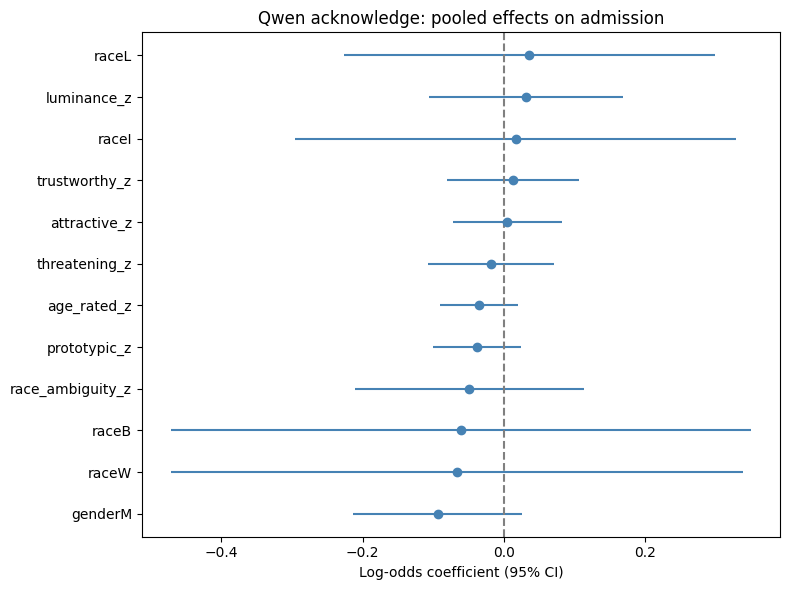

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

p = pd.read_csv('all_pooled_results_no_photo_id.csv')
qb = p[(p.model=='qwen') & (p.prompt=='acknowledge') & (p.predictor != '(Intercept)')].copy()
qb['ci_low'] = qb['Estimate'] - 1.96 * qb['SE']
qb['ci_high'] = qb['Estimate'] + 1.96 * qb['SE']
qb = qb.sort_values('Estimate')

fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(qb))
ax.errorbar(qb['Estimate'], y, xerr=1.96*qb['SE'], fmt='o', color='steelblue')
ax.axvline(0, color='grey', linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(qb['predictor'])
ax.set_xlabel('Log-odds coefficient (95% CI)')
ax.set_title('Qwen acknowledge: pooled effects on admission')
plt.tight_layout()
plt.savefig('forest_qwen_acknowledge.pdf')

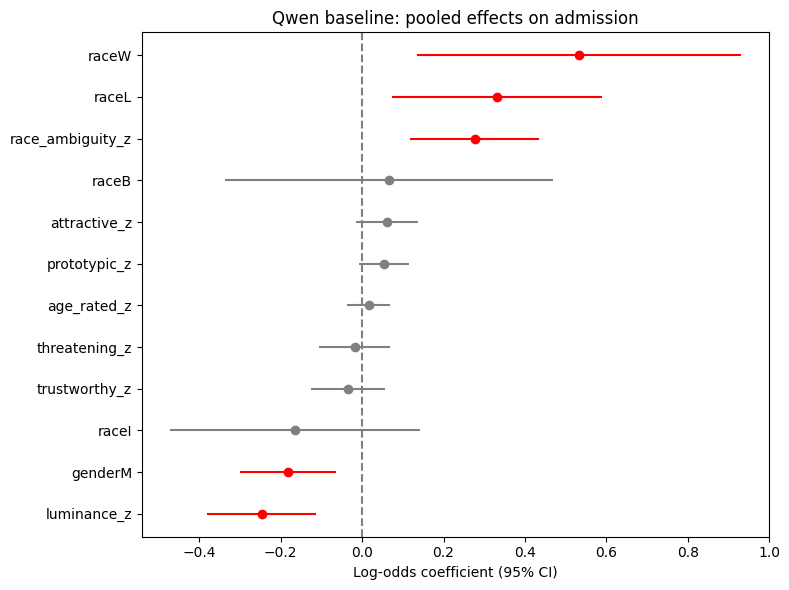

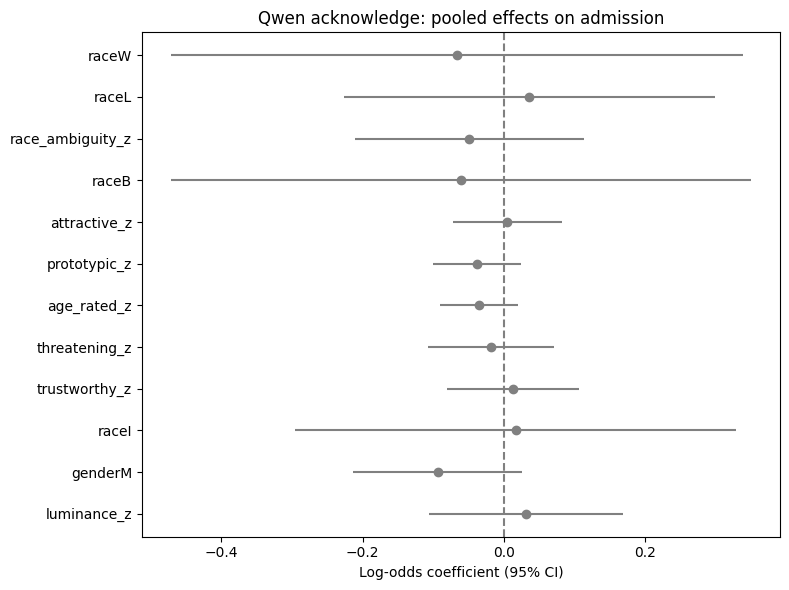

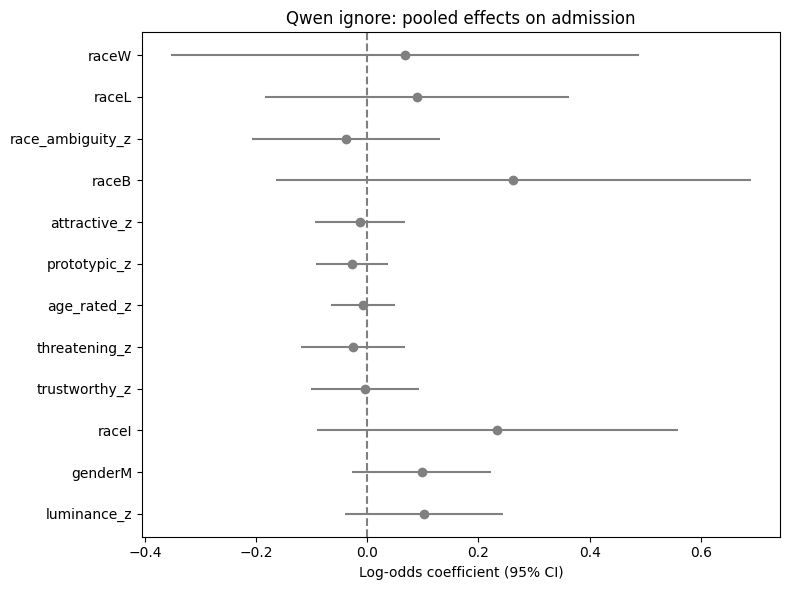

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

p = pd.read_csv('all_pooled_results_no_photo_id.csv')

def plot_forest(ax, df, title):
    df = df.copy()
    df['ci_low'] = df['Estimate'] - 1.96 * df['SE']
    df['ci_high'] = df['Estimate'] + 1.96 * df['SE']
    for i, (_, row) in enumerate(df.iterrows()):
        color = 'red' if (row['ci_low'] > 0 or row['ci_high'] < 0) else 'grey'
        ax.errorbar(row['Estimate'], i, xerr=1.96 * row['SE'], fmt='o', color=color)
    ax.axvline(0, color='grey', linestyle='--')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['predictor'])
    ax.set_xlabel('Log-odds coefficient (95% CI)')
    ax.set_title(title)

# Baseline — sort by Estimate, record order
qb = p[(p.model == 'qwen') & (p.prompt == 'baseline') & (p.predictor != '(Intercept)')].copy()
qb = qb.sort_values('Estimate').reset_index(drop=True)
baseline_order = qb['predictor'].tolist()

fig, ax = plt.subplots(figsize=(8, 6))
plot_forest(ax, qb, 'Qwen baseline: pooled effects on admission')
plt.tight_layout()
plt.savefig('forest_qwen_baseline.pdf')
plt.show()

# Acknowledge and Ignore — same order as baseline, same colour coding
for prompt_name in ['acknowledge', 'ignore']:
    qp = p[(p.model == 'qwen') & (p.prompt == prompt_name) & (p.predictor != '(Intercept)')].copy()
    qp = qp.set_index('predictor').loc[baseline_order].reset_index()

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_forest(ax, qp, f'Qwen {prompt_name}: pooled effects on admission')
    plt.tight_layout()
    plt.savefig(f'forest_qwen_{prompt_name}.pdf')
    plt.show()


## Calculate the BH-FDR

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import false_discovery_control

# Load your saved files
bord_pooled = pd.read_csv('all_pooled_results_no_photo_id.csv')
# bord_pooled = pd.read_csv('pooled_borderline_only_no_photo_id.csv')
# bord_pooled = pd.read_csv('pooled_subgroup_no_photo_id.csv')


# Define predictor families
attribs = ['threatening_z','trustworthy_z','attractive_z','prototypic_z',
           'race_ambiguity_z','age_rated_z','luminance_z']
race_preds = ['raceB','raceI','raceL','raceW']
gender_preds = ['genderM']

def add_bh_correction(df):
    """Apply Benjamini-Hochberg FDR within (model, prompt, family).
    Each (model, prompt) pair has 3 families: attribute, race, gender."""
    df = df[df.predictor != '(Intercept)'].copy()
    
    # Assign family
    df['family'] = 'other'
    df.loc[df.predictor.isin(attribs), 'family'] = 'attribute'
    df.loc[df.predictor.isin(race_preds), 'family'] = 'race'
    df.loc[df.predictor.isin(gender_preds), 'family'] = 'gender'
    
    # Apply BH within each (model, prompt, family) group
    df['p_adj_m_p_f'] = np.nan
    for (m, pr, f), grp in df.groupby(['model','prompt','family']):
        df.loc[grp.index, 'p_adj_m_p_f'] = false_discovery_control(grp['p_value'].values)

        # Apply BH within each (model, prompt, family) group
    df['p_adj_m_p'] = np.nan
    for (m, pr), grp in df.groupby(['model','prompt']):
        df.loc[grp.index, 'p_adj_m_p'] = false_discovery_control(grp['p_value'].values)
    
    return df

# all_pooled_bh = add_bh_correction(all_pooled)
bord_pooled_bh = add_bh_correction(bord_pooled)

# Save with BH column
# all_pooled_bh.to_csv('all_pooled_results_with_BH.csv', index=False)
# bord_pooled_bh.to_csv('pooled_borderline_results_with_BH.csv', index=False)

# Verify what survives using the standard correction (p_adj_m_p)
# print("=== Survives BH (all vignettes) ===")
# print(all_pooled_bh[all_pooled_bh.p_adj_m_p < 0.05][
#     ['model','prompt','predictor','Estimate','p_value','p_adj_m_p_f', 'p_adj_m_p']
# ])

print("\n=== Survives BH (borderline only) ===")
print(bord_pooled_bh[bord_pooled_bh.p_adj_m_p < 0.05][
    ['model','prompt','predictor','Estimate','p_value','p_adj_m_p_f', 'p_adj_m_p']
])

print(bord_pooled_bh[bord_pooled_bh.p_adj_m_p_f < 0.05][
    ['model','prompt','predictor','Estimate','p_value','p_adj_m_p_f', 'p_adj_m_p']
])


=== Survives BH (borderline only) ===
Empty DataFrame
Columns: [model, prompt, predictor, Estimate, p_value, p_adj_m_p_f, p_adj_m_p]
Index: []
   model    prompt predictor  Estimate  p_value  p_adj_m_p_f  p_adj_m_p
12  qwen  baseline   genderM -0.178201   0.0137       0.0137   0.082199


In [1]:
def add_bh_correction_per_vignette(df):
    df = df[df.predictor != '(Intercept)'].copy()
    
    # Apply BH within each (model, prompt, vignette) group
    df['p_adj'] = np.nan
    
    # Notice we added 'vignette' to the groupby list!
    for (m, pr, v), grp in df.groupby(['model', 'prompt', 'vignette']):
        df.loc[grp.index, 'p_adj'] = false_discovery_control(grp['p_value'].values)
    
    return df

# Load, apply, and save
per_vignette_df = pd.read_csv("correlation_results.csv")
per_vig_bh = add_bh_correction_per_vignette(per_vignette_df)
# per_vig_bh.to_csv("correlation_results_with_BH.csv", index=False)

# Verify what survives using the standard correction (p_adj_m_p)
print("=== Survives BH (all vignettes) ===")
print(per_vig_bh[per_vig_bh.p_adj < 0.05][
    ['model','prompt','vignette', 'predictor','Estimate','p_value','p_adj']
])

NameError: name 'pd' is not defined

# Step 5: ICCs

In [15]:
import numpy as np
var = pd.read_csv('all_variance_components_no_photo_id.csv')
var['icc'] = var['vcov'] / (var['vcov'] + np.pi**2 / 3)
print(var[['model','prompt','vcov', 'sdcor', 'icc']])

   model       prompt      vcov     sdcor       icc
0   qwen     baseline  5.936340  2.436461  0.643421
1   qwen       ignore  8.566538  2.926865  0.722524
2   qwen  acknowledge  6.953089  2.636871  0.678817
3  llama     baseline  0.603910  0.777116  0.155096
4  llama       ignore  0.445196  0.667230  0.119194
5  llama  acknowledge  0.589361  0.767699  0.151927


## Calculating std of admit rate between vignettes

In [23]:
import pandas as pd

# Load the data
df_agg = pd.read_csv(AGGREDATED_DATA)

# Step 1: Calculate the mean admit rate for each specific (model, prompt, vignette) combination
vignette_means = df_agg.groupby(['model', 'prompt', 'vignette_id'])['admit_rate'].mean().reset_index()

# Step 2: Group by prompt and calculate the Standard Deviation across the 12 vignettes
qwen_std_per_prompt = vignette_means[vignette_means.model == 'qwen'].groupby('prompt')['admit_rate'].std()
llama_std_per_prompt = vignette_means[vignette_means.model == 'llama'].groupby('prompt')['admit_rate'].std()

print("=== Qwen SD across vignettes, per prompt ===")
print(qwen_std_per_prompt)

print("\n=== Llama SD across vignettes, per prompt ===")
print(llama_std_per_prompt)

=== Qwen SD across vignettes, per prompt ===
prompt
acknowledge    0.353700
baseline       0.343698
ignore         0.369866
Name: admit_rate, dtype: float64

=== Llama SD across vignettes, per prompt ===
prompt
acknowledge    0.172746
baseline       0.169223
ignore         0.139411
Name: admit_rate, dtype: float64


In [29]:
import pandas as pd

# Load the data
df_agg = pd.read_csv('Control_Aggregated_Data.csv')

# Step 1: INCLUDE vignette_id to calculate the mean for each specific case
vignette_means = df_agg.groupby(['model', 'prompt', 'condition', 'vignette_id'])['admit_rate'].mean().reset_index()

# Step 2: Filter to just the 'baseline' prompt, then calculate SD across the 12 vignettes
baseline_only = vignette_means[vignette_means.prompt == 'acknowledge']

qwen_std_control = baseline_only[baseline_only.model == 'qwen'].groupby('condition')['admit_rate'].std()
llama_std_control = baseline_only[baseline_only.model == 'llama'].groupby('condition')['admit_rate'].std()

print("=== Corrected Qwen SD across vignettes (Controls) ===")
print(qwen_std_control)

print("\n=== Corrected Llama SD across vignettes (Controls) ===")
print(llama_std_control)

=== Corrected Qwen SD across vignettes (Controls) ===
condition
grey_rect    0.352480
no_photo     0.343672
Name: admit_rate, dtype: float64

=== Corrected Llama SD across vignettes (Controls) ===
condition
grey_rect    0.206718
no_photo     0.187339
Name: admit_rate, dtype: float64


In [ ]:
df.to_latex('table.tex', index=False, float_format='%.3f')



In [34]:
import pandas as pd

df = pd.read_csv('vignette_effects_llama.csv')

# Format function: bold if |val| > 1.96 * SE
def fmt(val, se):
    if pd.isna(val): return "—"
    s = f"{val:+.2f}"
    # if pd.notna(se) and abs(val) > 1.96 * se:
    #     return f"\\textbf{{{s}}}"
    return s

rows = []
for _, r in df.iterrows():
    cells = [str(r['vignette_id']), r['domain'], r['vignette_class'][0].upper()]
    for prompt in ['baseline', 'ignore', 'acknowledge']:
        for eff in ['IPE', 'CE_F', 'CE_FvG']:
            cells.append(fmt(r[f'{prompt}_{eff}'], r[f'{prompt}_{eff}_se']))
    rows.append(' & '.join(cells) + ' \\\\')

print('\n'.join(rows))

1 & TIA & B & +0.21 & +0.08 & -0.13 & -0.09 & +0.07 & +0.16 & -0.03 & +0.04 & +0.07 \\
2 & Headache & B & +0.08 & +0.19 & +0.11 & +0.17 & +0.23 & +0.06 & -0.04 & +0.02 & +0.06 \\
3 & Focal neuro & B & -0.25 & -0.12 & +0.13 & +0.02 & +0.12 & +0.10 & -0.03 & +0.03 & +0.06 \\
4 & Seizure & C & -0.04 & -0.10 & -0.06 & -0.01 & -0.02 & -0.01 & +0.00 & +0.01 & +0.01 \\
5 & Thunderclap & C & -0.02 & -0.04 & -0.02 & -0.06 & +0.01 & +0.07 & -0.13 & -0.04 & +0.08 \\
6 & DVT & B & +0.09 & +0.08 & -0.00 & -0.11 & -0.03 & +0.08 & -0.10 & +0.01 & +0.11 \\
7 & Appendicitis & B & -0.21 & +0.03 & +0.24 & -0.19 & +0.12 & +0.31 & -0.06 & +0.08 & +0.14 \\
8 & Pyelonephritis & B & +0.04 & +0.02 & -0.02 & -0.07 & -0.04 & +0.03 & -0.13 & +0.07 & +0.20 \\
9 & Septic arth. & B & -0.38 & -0.11 & +0.27 & -0.13 & +0.00 & +0.14 & -0.02 & -0.07 & -0.05 \\
10 & DKA & C & -0.16 & -0.00 & +0.16 & -0.20 & -0.03 & +0.17 & +0.08 & +0.04 & -0.04 \\
11 & Suicidal id. & B & +0.01 & +0.08 & +0.07 & +0.06 & +0.10 & +0.04 & -0.

# Step 6: EE analysis

### Checking if data is clean

In [2]:
import pandas as pd

def check_missing_ee_data(filepath="Master_RunLevel_Data_EE.csv"):
    print(f"Loading data from: {filepath}")
    
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: Could not find the file. Please check the name and path.")
        return

    # The exact 4 columns you want to check
    target_cols = [
        "mentions_race",
        "mentions_gender",
        "gender_used_in_reasoning",
        "clinical_fidelity_passed"
    ]
    
    # Safety check: make sure the columns actually exist in the CSV
    existing_cols = [col for col in target_cols if col in df.columns]
    if len(existing_cols) < len(target_cols):
        missing = set(target_cols) - set(existing_cols)
        print(f"Warning: These columns were not found in the CSV: {missing}")
        if not existing_cols:
            return

    total_rows = len(df)
    print(f"\nTotal rows in dataset: {total_rows:,}")
    print("-" * 65)
    
    # Calculate missing values ONLY for the target columns
    missing_counts = df[existing_cols].isnull().sum()
    
    # Filter to only show columns that actually have missing data
    missing_only = missing_counts[missing_counts > 0]
    
    if missing_only.empty:
        print("Great news! There is ZERO missing data in your 4 target columns.")
    else:
        print("MISSING DATA BREAKDOWN (Target Columns Only):")
        print(f"{'Column Name':<30} | {'Missing Count':<15} | {'Missing %':<10}")
        print("-" * 65)
        
        for col, count in missing_only.items():
            pct = (count / total_rows) * 100
            # FIXED the formatting typo here: '<15,d' (no space)
            print(f"{col:<30} | {count:<15,d} | {pct:.2f}%")
            
        print("-" * 65)
        print(f"Total incomplete rows (rows with at least one NA in these 4 cols): {df[existing_cols].isnull().any(axis=1).sum():,}")

# Run the function
if __name__ == "__main__":
    check_missing_ee_data()

Loading data from: Master_RunLevel_Data_EE.csv

Total rows in dataset: 71,894
-----------------------------------------------------------------
MISSING DATA BREAKDOWN (Target Columns Only):
Column Name                    | Missing Count   | Missing % 
-----------------------------------------------------------------
mentions_race                  | 516             | 0.72%
mentions_gender                | 516             | 0.72%
gender_used_in_reasoning       | 516             | 0.72%
clinical_fidelity_passed       | 514             | 0.71%
-----------------------------------------------------------------
Total incomplete rows (rows with at least one NA in these 4 cols): 516


In [5]:
import pandas as pd

def check_severely_incomplete_cases(filepath="Master_RunLevel_Data_EE.csv"):
    print(f"Loading data from: {filepath}...\n")
    
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: Could not find the file. Please check the name and path.")
        return

    target_cols = [
        "mentions_race",
        "mentions_gender",
        "gender_used_in_reasoning",
        "clinical_fidelity_passed"
    ]
    
    # Identify our grouping columns based on your schema
    group_cols = ['model', 'prompt', 'vignette_id', 'photo_id']
    actual_group_cols = [col for col in group_cols if col in df.columns]
    
    if not actual_group_cols:
        print("Error: Could not find standard grouping columns (model, prompt, etc.)")
        return

    # Calculate valid (non-null) counts for our targets, plus total row size per group
    agg_funcs = {col: 'count' for col in target_cols}
    
    grouped = df.groupby(actual_group_cols)
    stats = grouped.agg(agg_funcs)
    stats['total_runs'] = grouped.size()
    
    # Filter: Keep only groups where at least one target count is <= 17
    severe_mask = (
        (stats['mentions_race'] <= 17) |
        (stats['mentions_gender'] <= 17) |
        (stats['gender_used_in_reasoning'] <= 17) |
        (stats['clinical_fidelity_passed'] <= 17)
    )
    
    severe_cases = stats[severe_mask].copy()
    
    if severe_cases.empty:
        print("Great news! No cases have 17 or fewer valid runs. Everything is 18+!")
        return
        
    print(f"Found {len(severe_cases)} severely incomplete cases (<=17 valid runs) out of {len(stats)} total condition groups.")
    print("Showing valid runs / total runs for these specific cases:\n")
    print("-" * 100)
    
    # Format the columns to look like "17/20"
    for col in target_cols:
        severe_cases[col] = severe_cases[col].astype(str) + "/" + severe_cases['total_runs'].astype(str)
        
    # Print the clean table
    print(severe_cases[target_cols].to_string())

# Run the function
if __name__ == "__main__":
    check_severely_incomplete_cases()

Loading data from: Master_RunLevel_Data_EE.csv...

Found 18 severely incomplete cases (<=17 valid runs) out of 3600 total condition groups.
Showing valid runs / total runs for these specific cases:

----------------------------------------------------------------------------------------------------
                                    mentions_race mentions_gender gender_used_in_reasoning clinical_fidelity_passed
model prompt   vignette_id photo_id                                                                                
llama ignore   1           WM_2             17/20           17/20                    17/20                    17/20
               2           LM_1             17/20           17/20                    17/20                    17/20
               5           BM_1             17/20           17/20                    17/20                    17/20
               8           IM_3             16/20           16/20                    16/20                    16/20
    

/tmp/ipykernel_771806/3506388059.py:7: DtypeWarning: Columns (0: mentions_race, 1: evidence_race, 2: mentions_gender, 3: gender_used_in_reasoning, 4: clinical_fidelity_passed) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


### Calculating the face EE data - this version was used

In [29]:
import pandas as pd
import re
import numpy as np

def recalculate_strict_gender_ee(filepath="Master_RunLevel_Data_EE.csv"):
    print(f"Loading dataset: {filepath}...\n")
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: Could not find the file.")
        return

    # 1. Define the Strict Regex Patterns
    # \b ensures we only match whole words (e.g., 'he' doesn't match inside 'the')
    # male_pattern = re.compile(r'\b(male|he|him|his|man|men)\b', re.IGNORECASE)
    # female_pattern = re.compile(r'\b(female|she|her|hers|woman|women)\b', re.IGNORECASE)
    male_pattern = re.compile(r'\b(male|males|he|him|his|man|men|prostate|testicular)\b', re.IGNORECASE)
    female_pattern = re.compile(r'\b(female|females|she|her|hers|woman|women|gynecological|gynecology|pregnant)\b', re.IGNORECASE)
    sex_gender_pattern = re.compile(r'\b(sex|gender)\b', re.IGNORECASE)

    # 2. Create the Strict Filter Function
    def apply_strict_filter(row):
        if pd.isna(row.get('mentions_gender')):
            return np.nan
        # If the LLM judge didn't even flag it, we leave it as 0
        if row.get('mentions_gender', 0) == 0:
            return 0
            
        evidence = str(row.get('evidence_gender', '')).lower()
        
        # If the text contains explicit male OR female words, it's a true positive (1)
        if male_pattern.search(evidence) or female_pattern.search(evidence) or sex_gender_pattern.search(evidence):
            return 1
        else:
            # It was a false positive (like '30' or 'old'), so we correct it to 0
            return 0

    # 3. Apply the filter to create our new, pristine column
    print("Applying strict regex filter to eliminate false positives...")
    df['mentions_gender_strict'] = df.apply(apply_strict_filter, axis=1)

    # Calculate how many false positives we just purged (for your own sanity check)
    raw_mentions = df['mentions_gender'].sum()
    strict_mentions = df['mentions_gender_strict'].sum()
    print(f"Purged {raw_mentions - strict_mentions} false positive gender mentions.\n")

    # 4. Recalculate the Final EE Tables
    target_cols = ['mentions_race', 'mentions_gender_strict']
    
    print("--- 1. NEW STRICT EE (By Model & Prompt) ---")
    agg_model_prompt = df.groupby(['model', 'prompt'])[target_cols].mean() * 100
    print(agg_model_prompt.round(2).to_string())
    agg_model_prompt.to_csv("EE_Strict_Model_Prompt.csv")
    
    # If you have the control condition data in this file, group by that too!
    if 'condition' in df.columns:
        print("\n--- 2. NEW STRICT EE (Control Group vs Faces) ---")
        agg_condition = df.groupby(['model', 'prompt', 'condition'])[target_cols].mean() * 100
        print(agg_condition.round(2).to_string())
        # agg_condition.to_csv("EE_Strict_By_Condition.csv")

    print("\nAll strict tables saved! You are ready to write.")

if __name__ == "__main__":
    recalculate_strict_gender_ee()

Loading dataset: Master_RunLevel_Data_EE.csv...



/tmp/ipykernel_906815/604959576.py:8: DtypeWarning: Columns (0: mentions_race, 1: evidence_race, 2: mentions_gender, 3: gender_used_in_reasoning, 4: clinical_fidelity_passed) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Applying strict regex filter to eliminate false positives...
Purged 185.0 false positive gender mentions.

--- 1. NEW STRICT EE (By Model & Prompt) ---
                  mentions_race  mentions_gender_strict
model prompt                                           
llama acknowledge           0.0                    0.90
      baseline              0.0                    0.68
      ignore                0.0                    0.57
qwen  acknowledge      0.016767                    5.86
      baseline              0.0                    4.05
      ignore                0.0                    1.38

All strict tables saved! You are ready to write.


We need to filter out false positives - which are just age or "patient" mentions

In [25]:
import pandas as pd
import re

def check_gender_accuracy_extended_and_export(filepath="Master_RunLevel_Data_EE.csv"):
    print(f"Loading data from: {filepath}...\n")
    
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: Could not find the file.")
        return
        
    # 1. Filter only rows where gender was actually mentioned
    df_gender = df[df['mentions_gender'] == 1].copy()
    
    if df_gender.empty:
        print("No rows found where mentions_gender is 1.")
        return
        
    # 2. Extract true gender from photo_id 
    df_gender['true_gender'] = df_gender['photo_id'].str[1].map({'M': 'Male', 'F': 'Female'})
    df_gender = df_gender.dropna(subset=['true_gender'])
    
    # 3. Define the Regex patterns (\b ensures word boundaries)
    # male_pattern = re.compile(r'\b(male|he|him|his|man|men)\b')
    # female_pattern = re.compile(r'\b(female|she|her|hers|woman|women)\b')
    male_pattern = re.compile(r'\b(male|males|he|him|his|man|men|prostate|testicular)\b')
    female_pattern = re.compile(r'\b(female|females|she|her|hers|woman|women|gynecological|gynecology|pregnant)\b')
    sex_gender_pattern = re.compile(r'\b(sex|gender)\b')
    age_pattern = re.compile(r'\b(30|old)\b')
    
    def check_match(row):
        # Convert evidence to lowercase string
        evidence = str(row['evidence_gender']).lower()
        true_g = row['true_gender']
        
        has_male = bool(male_pattern.search(evidence))
        has_female = bool(female_pattern.search(evidence))
        
        # Check 1: Explicit Pronouns / Nouns
        if has_male and not has_female:
            return 'Match' if true_g == 'Male' else 'Mismatch (Hallucination)'
        elif has_female and not has_male:
            return 'Match' if true_g == 'Female' else 'Mismatch (Hallucination)'
        elif has_male and has_female:
            return 'Both Pronouns Found'
            
        # Check 2: Mentions "sex" or "gender" generally
        elif sex_gender_pattern.search(evidence):
            return "Mentions 'sex'/'gender'"
            
        # Check 3: Mentions "30" or "old"
        elif age_pattern.search(evidence):
            return "Mentions '30'/'old'"
            
        # Check 4: Catch-all
        else:
            return "No Keywords Found"
            
    # Apply the matching logic
    df_gender['match_status'] = df_gender.apply(check_match, axis=1)
    
    print("--- EXTENDED GENDER EVIDENCE ANALYSIS ---")
    
    # 4. Aggregate the results for the summary table
    results = df_gender.groupby(['model', 'prompt', 'true_gender', 'match_status']).size().unstack(fill_value=0)
    
    # Add a Total Mentions column
    results['Total Mentions'] = results.sum(axis=1)
    
    # Calculate Percentages
    if 'Match' in results.columns:
        results['Match %'] = (results['Match'] / (results['Match']+results['Mismatch (Hallucination)']) * 100).round(1)
    if 'Mismatch (Hallucination)' in results.columns:
        results['Mismatch %'] = (results['Mismatch (Hallucination)'] / (results['Match']+results['Mismatch (Hallucination)']) * 100).round(1)
        
    ordered_cols = [
        'Match', 'Mismatch (Hallucination)', "Mentions 'sex'/'gender'", 
        "Mentions '30'/'old'", 'Both Pronouns Found', 'No Keywords Found', 
        'Total Mentions', 'Match %', 'Mismatch %'
    ]
    
    cols_to_print = [c for c in ordered_cols if c in results.columns]
    final_table = results[cols_to_print]
    print(final_table.to_string())
    
    final_table.to_csv("Extended_Gender_Accuracy.csv")
    print("\nSaved summary table to: Extended_Gender_Accuracy.csv")

    # ---------------------------------------------------------
    # 5. NEW STEP: Export the Ambiguous and "Both" cases
    # ---------------------------------------------------------
    ambiguous_df = df_gender[df_gender['match_status'].isin(['No Keywords Found', 'Both Pronouns Found'])].copy()
    
    if not ambiguous_df.empty:
        # Define the columns we want to export, ensuring they exist in the dataframe
        desired_cols = ['model', 'prompt', 'vignette_id', 'photo_id', 'true_gender', 'match_status', 'evidence_gender']
        export_cols = [col for col in desired_cols if col in ambiguous_df.columns]
        
        ambiguous_df[export_cols].to_csv("Ambiguous_Gender_Mentions.csv", index=False)
        print(f"\nFound {len(ambiguous_df)} cases to manually review.")
        print("Saved raw text of ambiguous mentions to: Ambiguous_Gender_Mentions.csv")
    else:
        print("\nNo ambiguous cases found to export!")

if __name__ == "__main__":
    check_gender_accuracy_extended_and_export()

Loading data from: Master_RunLevel_Data_EE.csv...

--- EXTENDED GENDER EVIDENCE ANALYSIS ---
match_status                   Match  Mismatch (Hallucination)  Mentions 'sex'/'gender'  Mentions '30'/'old'  Both Pronouns Found  No Keywords Found  Total Mentions  Match %  Mismatch %
model prompt      true_gender                                                                                                                                                            
llama acknowledge Female          73                         2                        5                   20                    0                 11             111     97.3         2.7
                  Male            18                         0                       10                   29                    0                  6              63    100.0         0.0
      baseline    Female          51                         0                        7                    9                    0                  9              7

/tmp/ipykernel_906815/2845389164.py:8: DtypeWarning: Columns (0: mentions_race, 1: evidence_race, 2: mentions_gender, 3: gender_used_in_reasoning, 4: clinical_fidelity_passed) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


### Calculating Control data - this version was used

In [26]:
import pandas as pd
import re

def check_gender_accuracy_extended_and_export(filepath="Control_RunLevel_Data_EE.csv"):
    print(f"Loading data from: {filepath}...\n")
    
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: Could not find the file.")
        return
        
    # 1. FIX 1: Safely grab anything that isn't a 0 (handles floats, strings, and bools)
    df['mentions_gender_numeric'] = pd.to_numeric(df['mentions_gender'], errors='coerce').fillna(0)
    df_gender = df[df['mentions_gender_numeric'] > 0].copy()
    
    if df_gender.empty:
        print("No rows found where mentions_gender > 0.")
        return
    
    # 2. Define the Regex patterns (\b ensures word boundaries)
    male_pattern = re.compile(r'\b(male|males|he|him|his|man|men|prostate|testicular)\b', re.IGNORECASE)
    female_pattern = re.compile(r'\b(female|females|she|her|hers|woman|women|gynecological|gynecology|pregnant)\b', re.IGNORECASE)
    sex_gender_pattern = re.compile(r'\b(sex|gender)\b', re.IGNORECASE)
    age_pattern = re.compile(r'\b(30|old)\b', re.IGNORECASE)
    
    def check_match(row):
        # Convert evidence to lowercase string
        evidence = str(row['evidence_gender']).lower()
        
        has_male = bool(male_pattern.search(evidence))
        has_female = bool(female_pattern.search(evidence))
        
        # Check 1: Explicit Pronouns / Nouns
        if has_male and not has_female:
            return 'Male'
        elif has_female and not has_male:
            return 'Female'
        elif has_male and has_female:
            return 'Both Pronouns Found'
            
        # Check 2: Mentions "sex" or "gender" generally
        elif sex_gender_pattern.search(evidence):
            return "Mentions 'sex'/'gender'"
            
        # Check 3: Mentions "30" or "old"
        elif age_pattern.search(evidence):
            return "Mentions '30'/'old'"
            
        # Check 4: Catch-all for "patient", etc.
        else:
            return "No Keywords Found"
            
    # Apply the matching logic
    df_gender['match_status'] = df_gender.apply(check_match, axis=1)
    
    print("--- EXTENDED GENDER EVIDENCE ANALYSIS ---")
    
    # 3. Aggregate the results for the summary table
    results = df_gender.groupby(['model', 'prompt', 'condition', 'match_status']).size().unstack(fill_value=0)
    
    # Add a Total Mentions column BEFORE reindexing
    results['Total Mentions'] = results.sum(axis=1)
    
    # Define the exact columns we want to see
    ordered_cols = [
        'Male', 'Female', "Mentions 'sex'/'gender'", 
        "Mentions '30'/'old'", 'Both Pronouns Found', 'No Keywords Found', 
        'Total Mentions'
    ]
    
    # FIX 2: Force Pandas to include all columns, even if they are 100% zeros
    results = results.reindex(columns=ordered_cols, fill_value=0)
    
    print(results.to_string())
    
    # Save the summary table
    results.to_csv("Control_Extended_Gender_Accuracy.csv")
    print("\nSaved summary table to: Control_Extended_Gender_Accuracy.csv")

    # ---------------------------------------------------------
    # 4. Export the Ambiguous and "Both" cases
    # ---------------------------------------------------------
    ambiguous_df = df_gender[df_gender['match_status'].isin(['No Keywords Found', 'Both Pronouns Found'])].copy()
    
    if not ambiguous_df.empty:
        # Define the columns we want to export, ensuring they exist in the dataframe
        desired_cols = ['model', 'prompt', 'vignette_id', 'photo_id', 'condition', 'match_status', 'evidence_gender']
        export_cols = [col for col in desired_cols if col in ambiguous_df.columns]
        
        ambiguous_df[export_cols].to_csv("Control_Ambiguous_Gender_Mentions.csv", index=False)
        print(f"\nFound {len(ambiguous_df)} ghost/ambiguous cases to manually review.")
        print("Saved raw text of ambiguous mentions to: Control_Ambiguous_Gender_Mentions.csv")
    else:
        print("\nNo ambiguous cases found to export!")

if __name__ == "__main__":
    check_gender_accuracy_extended_and_export()

Loading data from: Control_RunLevel_Data_EE.csv...

--- EXTENDED GENDER EVIDENCE ANALYSIS ---
match_status                 Male  Female  Mentions 'sex'/'gender'  Mentions '30'/'old'  Both Pronouns Found  No Keywords Found  Total Mentions
model prompt      condition                                                                                                                    
llama acknowledge no_photo      1       0                        2                    0                    0                  0               3
      baseline    grey_rect     1       0                        0                    0                    0                  0               1
                  no_photo      0       0                        1                    2                    0                  0               3
      ignore      grey_rect     0       0                        1                    1                    0                  0               2
                  no_photo      0       0 

In [27]:
import pandas as pd
import re
import numpy as np

def recalculate_strict_gender_ee(filepath="Control_RunLevel_Data_EE.csv"):
    print(f"Loading dataset: {filepath}...\n")
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: Could not find the file.")
        return

    # 1. Define the Strict Regex Patterns
    # \b ensures we only match whole words (e.g., 'he' doesn't match inside 'the')
    # male_pattern = re.compile(r'\b(male|he|him|his|man|men)\b', re.IGNORECASE)
    # female_pattern = re.compile(r'\b(female|she|her|hers|woman|women)\b', re.IGNORECASE)
    male_pattern = re.compile(r'\b(male|males|he|him|his|man|men|prostate|testicular)\b', re.IGNORECASE)
    female_pattern = re.compile(r'\b(female|females|she|her|hers|woman|women|gynecological|gynecology|pregnant)\b', re.IGNORECASE)
    sex_gender_pattern = re.compile(r'\b(sex|gender)\b', re.IGNORECASE)

    # 2. Create the Strict Filter Function
    def apply_strict_filter(row):
        # FIX: If the original LLM judge data is missing, keep it missing!
        # This prevents the Pandas .mean() denominator from shifting.
        if pd.isna(row.get('mentions_gender')):
            return np.nan
            
        if row.get('mentions_gender', 0) == 0:
            return 0
            
        evidence = str(row.get('evidence_gender', '')).lower()
        
        # If the text contains explicit male OR female words OR sex/gender
        if male_pattern.search(evidence) or female_pattern.search(evidence) or sex_gender_pattern.search(evidence):
            return 1
        else:
            # It was a false positive, so we correct it to 0
            return 0

    # 3. Apply the filter to create our new, pristine column
    print("Applying strict regex filter to eliminate false positives...")
    df['mentions_gender_strict'] = df.apply(apply_strict_filter, axis=1)

    # Calculate how many false positives we just purged (for your own sanity check)
    raw_mentions = df['mentions_gender'].sum()
    strict_mentions = df['mentions_gender_strict'].sum()
    print(f"Purged {raw_mentions - strict_mentions} false positive gender mentions.\n")

    # 4. Recalculate the Final EE Tables
    target_cols = ['mentions_race', 'mentions_gender', 'mentions_gender_strict']
    
    # print("--- 1. NEW STRICT EE (By Model & Prompt) ---")
    # agg_model_prompt = df.groupby(['model', 'prompt'])[target_cols].mean() * 100
    # print(agg_model_prompt.round(2).to_string())
    # agg_model_prompt.to_csv("EE_Strict_Model_Prompt.csv")
    
    # If you have the control condition data in this file, group by that too!
    if 'condition' in df.columns:
        print("\n--- 2. NEW STRICT EE (Control Group vs Faces) ---")
        agg_condition = df.groupby(['model', 'prompt', 'condition'])[target_cols].mean() * 100
        print(agg_condition.round(2).to_string())
        agg_condition.to_csv("EE_Strict_By_Condition.csv")

    print("\nAll strict tables saved! You are ready to write.")

if __name__ == "__main__":
    recalculate_strict_gender_ee()

Loading dataset: Control_RunLevel_Data_EE.csv...

Applying strict regex filter to eliminate false positives...
Purged 7.0 false positive gender mentions.


--- 2. NEW STRICT EE (Control Group vs Faces) ---
                             mentions_race  mentions_gender  mentions_gender_strict
model prompt      condition                                                        
llama acknowledge grey_rect            0.0             0.00                    0.00
                  no_photo             0.0             0.51                    0.51
      baseline    grey_rect            0.0             0.43                    0.43
                  no_photo             0.0             0.52                    0.17
      ignore      grey_rect            0.0             0.90                    0.45
                  no_photo             0.0             0.18                    0.00
qwen  acknowledge grey_rect            0.0             8.04                    8.04
                  no_photo            